## Notebook 7: Lotka Volterra

This notebook illustrates the training and prediction of a Neural Ordinary Differential Equation (NODEs) model.  The data is fictitiously generated by solving the Lotka-Volterra model

$\frac{dx}{dt}=\alpha x -\beta xy$

$\frac{dy}{dt}=-\gamma y +\delta xy$

with initial condition $x(0)=1$ and $y(0)=1$.   In this notebook, we will use $\alpha=1.5$, $\beta=1.0$, $\gamma=3.0$ $\delta=1.0$. Training data is generated for $t\in[0,20]$. The intention is to try to use the NODEs model to predict the solution for $t\in[0,50]$.    

The NODEs model look like


$\frac{d\vec{u}}{dt}=\vec{NN}(\vec{u};\vec{p})$


The Neural Network has two inputs, $u_1$ and $u_2$ and two outputs $du_1/dt$ and $du_2/dt$.  

In [1]:
using ComponentArrays
using Lux
using DiffEqFlux 
using OrdinaryDiffEq
using SciMLSensitivity
using Optimization
using OptimizationOptimisers
using Random
using CairoMakie
using MLUtils
using OrdinaryDiffEqTsit5

Parameters for Training Data

In [2]:
rng = Xoshiro(0)
u0 = Float32[1.0;1.0]
datasize = 500
tspan = (0.0f0, 20.0f0)
tsteps = range(tspan[1], tspan[2]; length = datasize)

EpanechnikovKernelBandwidth=0.02
noise=0.1

0.1

Parameters for Validation Data

In [3]:
tspan2 = (0.0f0, 50.0f0)
tsteps2 = range(tspan2[1], tspan2[2]; length = 500)

0.0f0:0.1002004f0:50.0f0

Training parameters

In [4]:
max_iter_colloc=2000
max_iter_NODEs=2000
learning_rate=0.01

0.01

Lotka Volterra equation


$\frac{du_1}{dt}=1.5 u_1 -u_1 u_2$

$\frac{du_2}{dt}=-3 u_2 +u_1u_2$

In [5]:
function trueODEfunc(du, u, p, t)
    du[1]=1.5*u[1]-u[1]*u[2]
    du[2]=-3*u[2]+u[1]*u[2]
end

trueODEfunc (generic function with 1 method)

Generating training data

In [6]:
prob_trueode = ODEProblem(trueODEfunc, u0, tspan)
data = Array(solve(prob_trueode, Tsit5(); saveat = tsteps)) .+ noise*randn(length(u0), datasize)

2×500 Matrix{Float64}:
 0.925678  1.00816   0.978904  0.929542  …  0.844074  1.19711   1.04076
 1.03196   0.825077  0.953659  0.689096     0.929698  0.765082  0.960427

Generating Validation data

In [7]:
prob_trueode_sol = ODEProblem(trueODEfunc, u0, tspan2)
data_true = Array(solve(prob_trueode_sol, Tsit5(); saveat = tsteps2)) 

2×500 Matrix{Float32}:
 1.0  1.06122   1.1444    1.24987   1.37877   …  1.24666   1.36633   1.5108
 1.0  0.820765  0.678548  0.566297  0.478191     0.637206  0.537629  0.459627

Plot to see how the training and validation data looks like

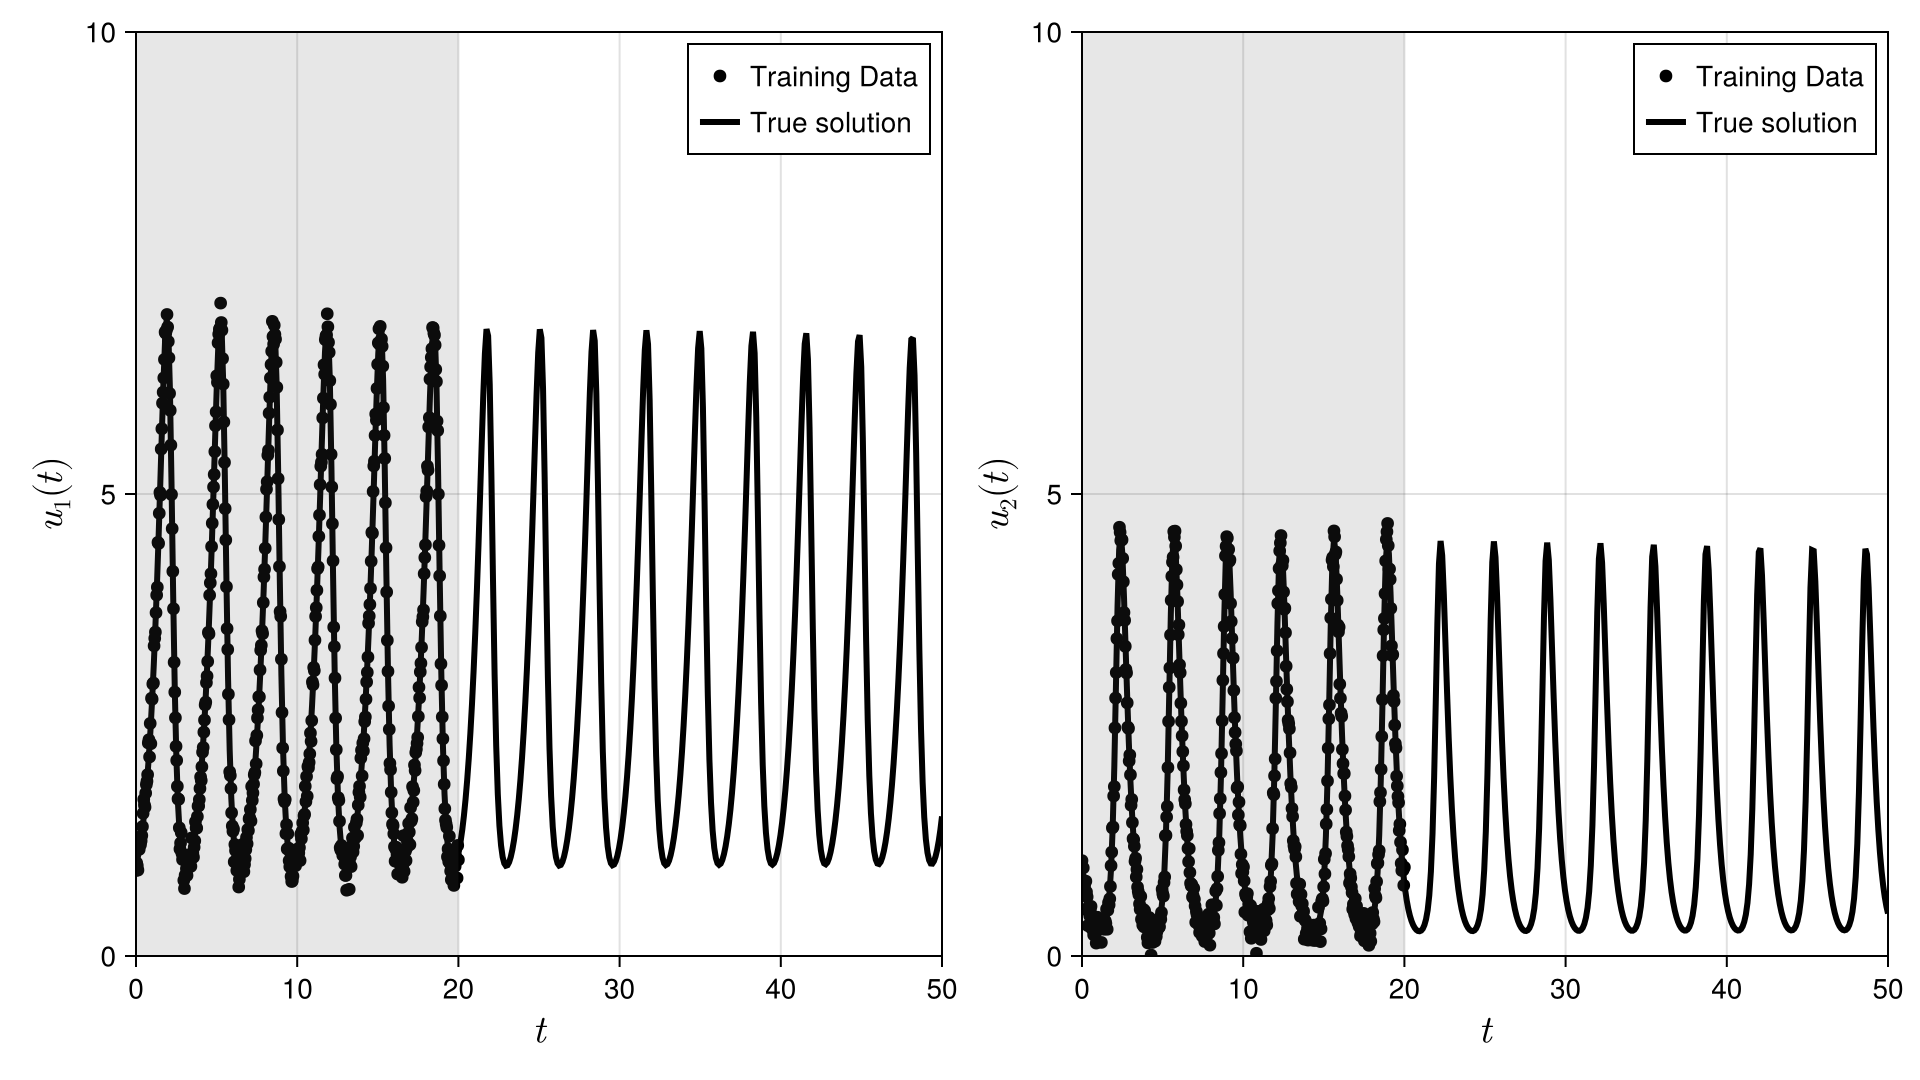

In [8]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)",title="")
CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,0,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)",title="")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,0,10)
#save("figures/07LotkaVolterraTrainingData.png", fig)
fig

Using the inbuilt `collocate_data()` function to smooth the data and approximate the time derivative of the data

In [9]:
du, u = collocate_data(data, tsteps, EpanechnikovKernel(),EpanechnikovKernelBandwidth)

([0.9776609232478928 1.0230709529117177 … 0.9937079326001523 1.138996985088897; -2.0865090988859896 -1.661955899857135 … -0.29419346464236273 0.29797905259636126], [0.9174174541142857 0.9609043694838897 … 1.0405478230523082 1.065282253237926; 0.954364480081428 0.9028037688170635 … 0.8680374443539074 0.813585791138129])

Plot the smoothed data to check if it looks reasonable

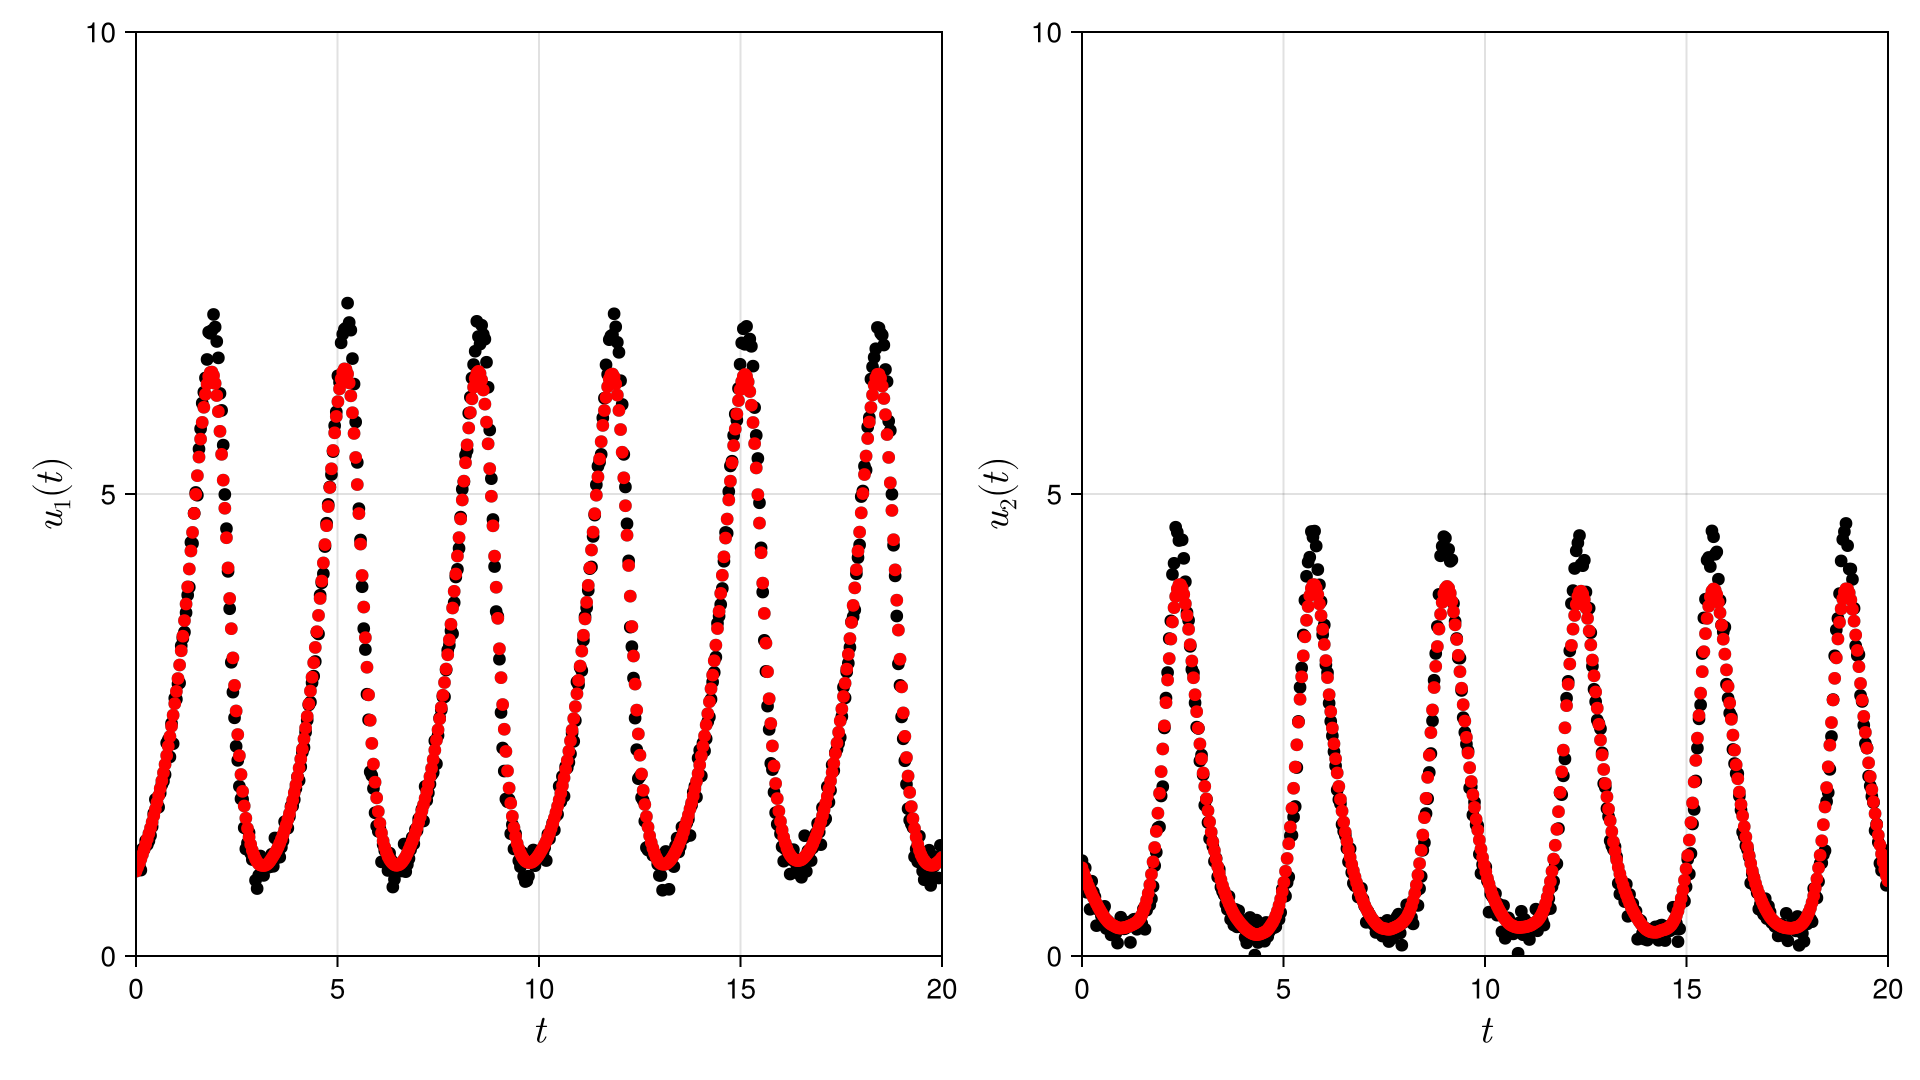

In [10]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")
CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black)
CairoMakie.scatter!(ax1,tsteps, u[1,:];color=:red)
xlims!(ax1,0,tspan[2])
ylims!(ax1,0,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black)
CairoMakie.scatter!(ax2,tsteps, u[2,:]; color=:red)
xlims!(ax2,0,tspan[2])
ylims!(ax2,0,10)
#save("colloc.png", fig)
fig

Plot the approximated derivative of the data to check if it looks reasonable

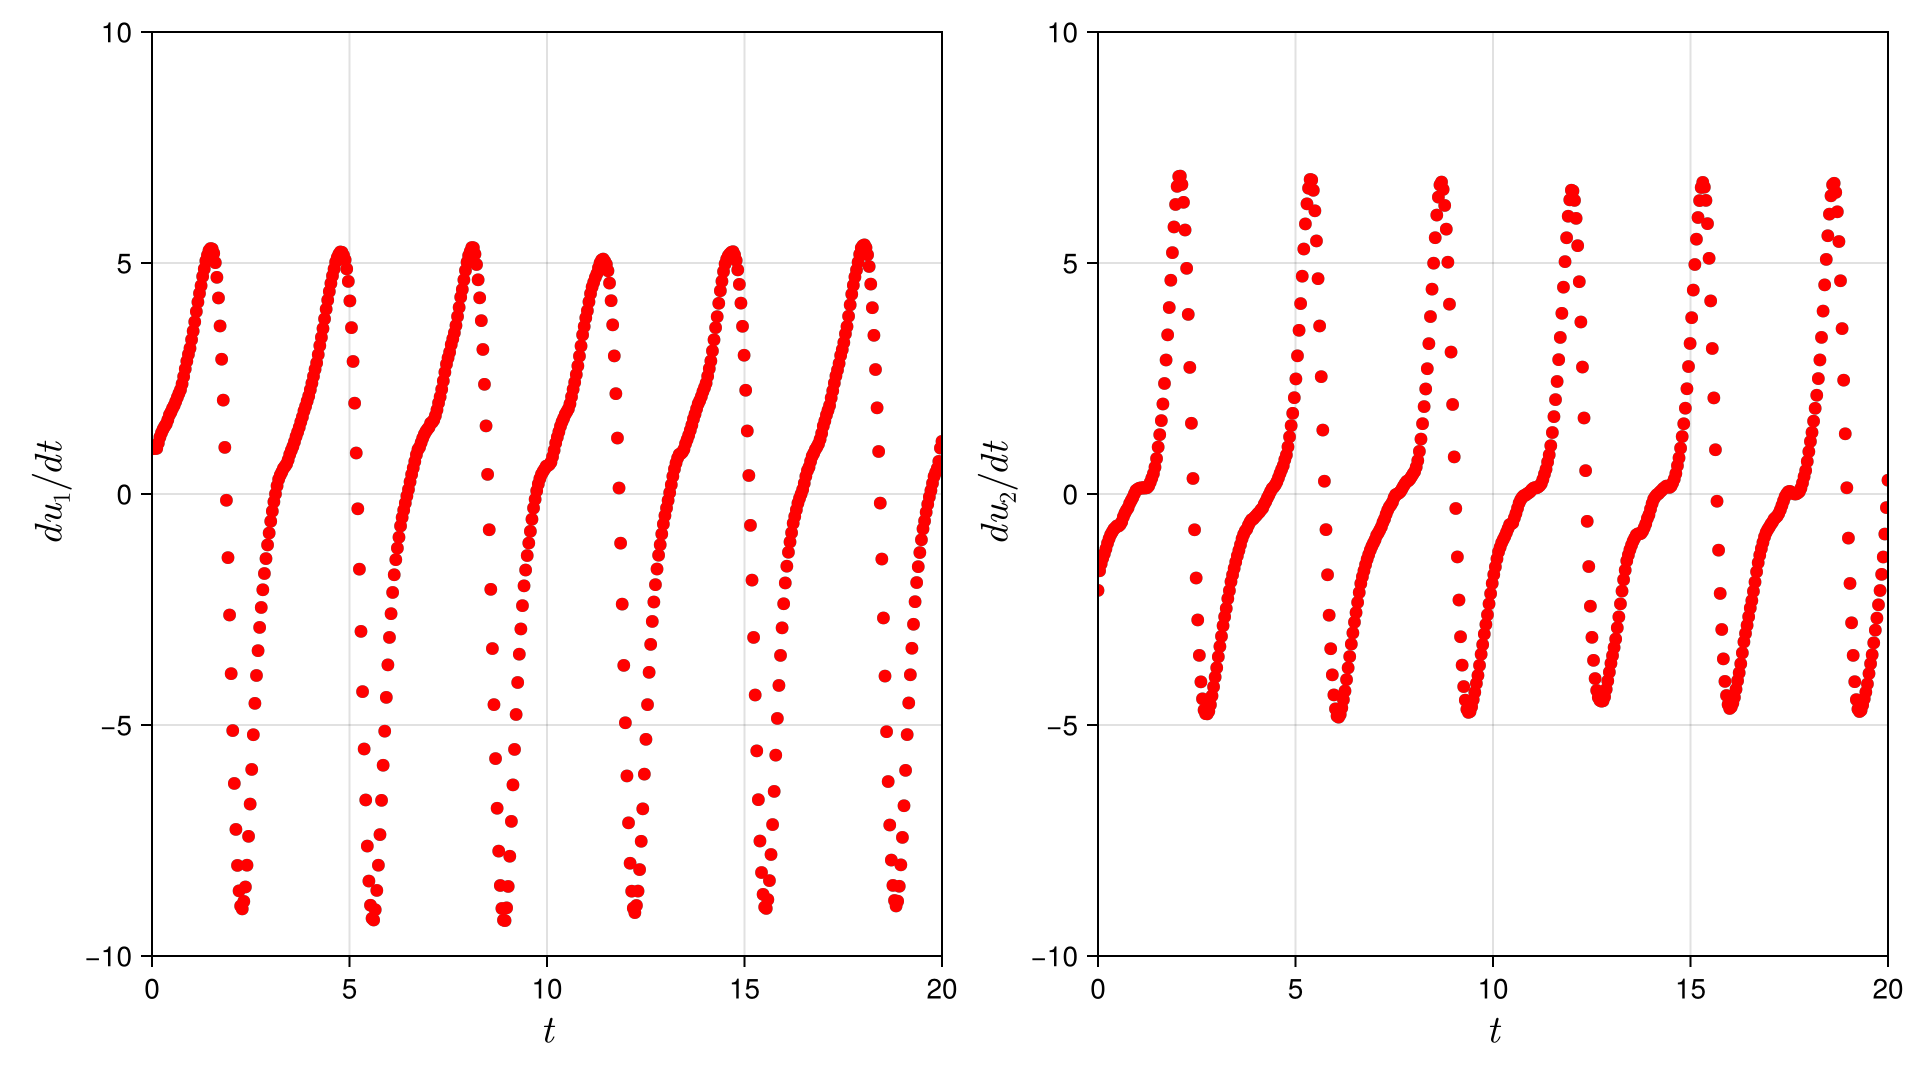

In [11]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)

ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"du_1/dt")
xlims!(ax1,0,tspan[2])
ylims!(ax1,-10,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"du_2/dt")
xlims!(ax2,0,tspan[2])
ylims!(ax2,-10,10)

CairoMakie.scatter!(ax1,tsteps, du[1,:];color=:red)
CairoMakie.scatter!(ax2,tsteps, du[2,:];color=:red)
fig

Set up architecture of Neural Network

In [12]:
dudtNODEs = Chain(Dense(2, 5, tanh),
            Dense(5, 5, tanh),
             Dense(5, 2))
pinit, st = Lux.setup(rng, dudtNODEs)

((layer_1 = (weight = Float32[-0.058096703 1.4784337; -0.38498044 -0.936009; … ; -1.7614043 -0.7860806; -1.2246865 0.65978104], bias = Float32[-0.2306831, -0.5425951, 0.5163813, -0.5524123, -0.119110115]), layer_2 = (weight = Float32[-1.0147992 -0.16287804 … -0.14458258 1.1619588; -0.2060021 1.0493203 … 1.0649743 1.2428114; … ; 0.5692708 0.51255274 … -1.1117479 -0.27292225; 0.26297426 -0.91578704 … 0.86948603 -0.70678467], bias = Float32[-0.29378006, 0.11851501, 0.11447332, -0.40796348, -0.16753744]), layer_3 = (weight = Float32[-0.49382704 -0.19511192 … 0.1928618 -0.26110658; -0.0077854805 0.5515388 … 0.28800184 0.20672485], bias = Float32[-0.28049797, -0.25374046])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

In [13]:
function loss(p,(du, u))
    cost = zero(first(p))
    for i in 1:size(du, 2)
        _du, _ = dudtNODEs(@view(u[:, i]), p, st)
        dui = @view du[:, i]
        cost += sum(abs2, _du  .- dui)
    end
    return 0.5*cost/size(du, 2)
end

loss (generic function with 1 method)

Collocation training

In [14]:
# Initialize a vector to store loss values
loss_history = Float64[]

callback = function (p, l)
    if p.iter % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((p, x) -> loss(p,(du,u)), adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(pinit),(du,u))
result_neuralode = Optimization.solve(optprob, OptimizationOptimisers.Adam(learning_rate); callback, epochs =max_iter_colloc)


┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Base.ReshapedArray{Float64, 2, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}, Tuple{}}]). Converting to common type to to attempt to use BLAS. This may be slow.
└ @ LuxLib.Impl /Users/asho/.julia/packages/LuxLib/zPBrt/src/impl/matmul.jl:198


Iteration: 100, Loss: 3.4626389876954886
Iteration: 200, Loss: 0.21421405637109076
Iteration: 300, Loss: 0.05191070298219219
Iteration: 400, Loss: 0.03723974022274494
Iteration: 500, Loss: 0.031110027773338822
Iteration: 600, Loss: 0.027938096717923522
Iteration: 700, Loss: 0.028838667364986317
Iteration: 800, Loss: 0.024226210275318807
Iteration: 900, Loss: 0.023250953278243
Iteration: 1000, Loss: 0.028852939083291035
Iteration: 1100, Loss: 0.022006764721261434
Iteration: 1200, Loss: 0.021593662757154745
Iteration: 1300, Loss: 0.021284784267832747
Iteration: 1400, Loss: 0.021016521335758223
Iteration: 1500, Loss: 0.022518221889291343
Iteration: 1600, Loss: 0.020625517902740337
Iteration: 1700, Loss: 0.02046630818443689
Iteration: 1800, Loss: 0.02044888285617129
Iteration: 1900, Loss: 0.020219124017618974
Iteration: 2000, Loss: 0.02011054991453876
Iteration: 2000, Loss: 0.02011054991453876


retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[0.38283265 0.54360974; 0.13751563 -0.45508608; … ; -2.6279998 -1.386752; -0.46066958 0.40056673], bias = Float32[-2.501443, 0.020609148, 0.98463184, -1.4211065, 0.21852586]), layer_2 = (weight = Float32[0.11249423 -1.7623183 … -1.3492942 1.5015725; -0.42692724 2.2234645 … 0.38661438 0.5747025; … ; -0.5825514 1.6497627 … -1.1129146 -0.9433063; 1.6889317 -1.9226055 … 1.0167328 -1.5126508], bias = Float32[0.91063553, 0.79633933, 0.89932585, -0.4066729, -0.31788903]), layer_3 = (weight = Float32[-2.3425715 3.2454574 … 1.6497664 -2.114097; -0.39278403 -1.5789288 … 2.646542 1.6263471], bias = Float32[-1.3796749, 1.2947658]))

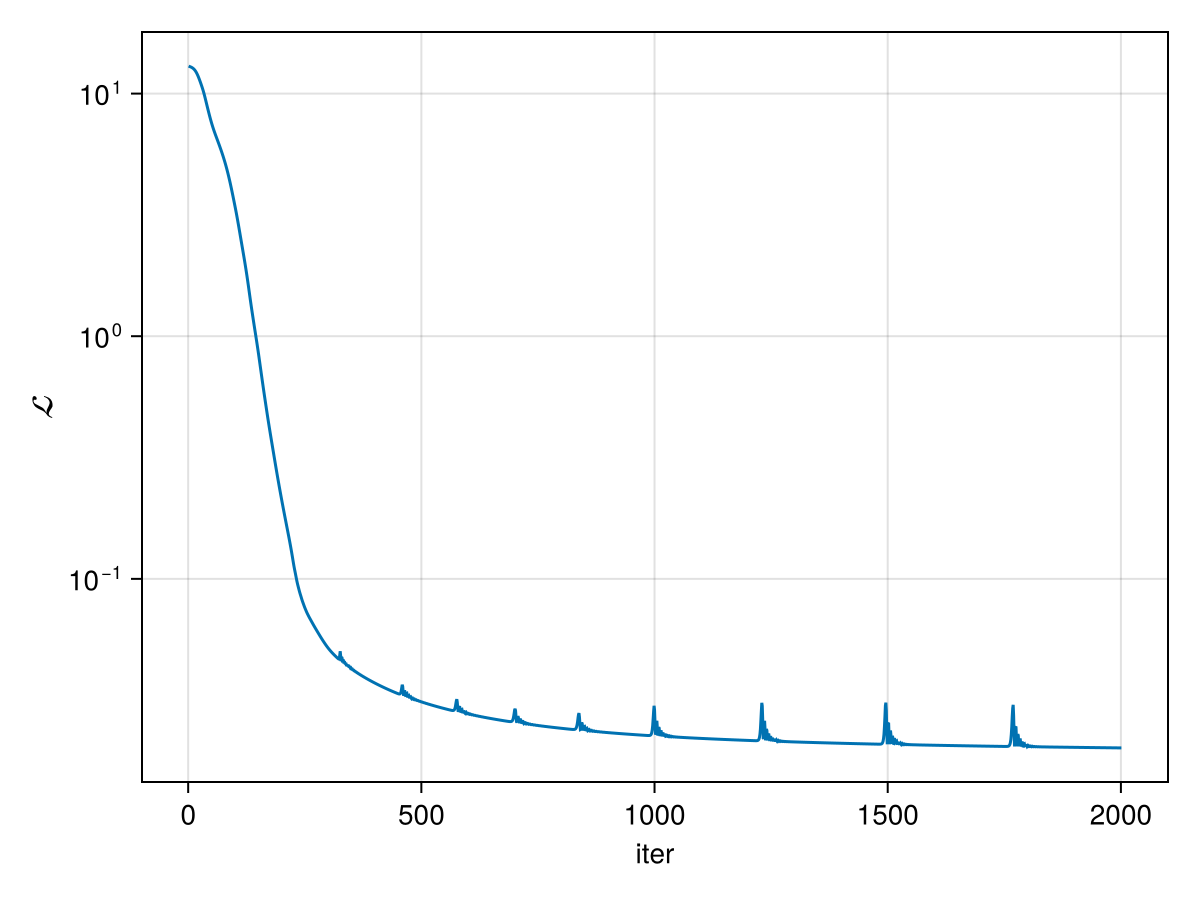

In [15]:
#Plot loss function
#
loss_history_collocation=copy(loss_history)
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel=L"\mathcal{L}")
CairoMakie.lines!(ax,loss_history_collocation)
fig


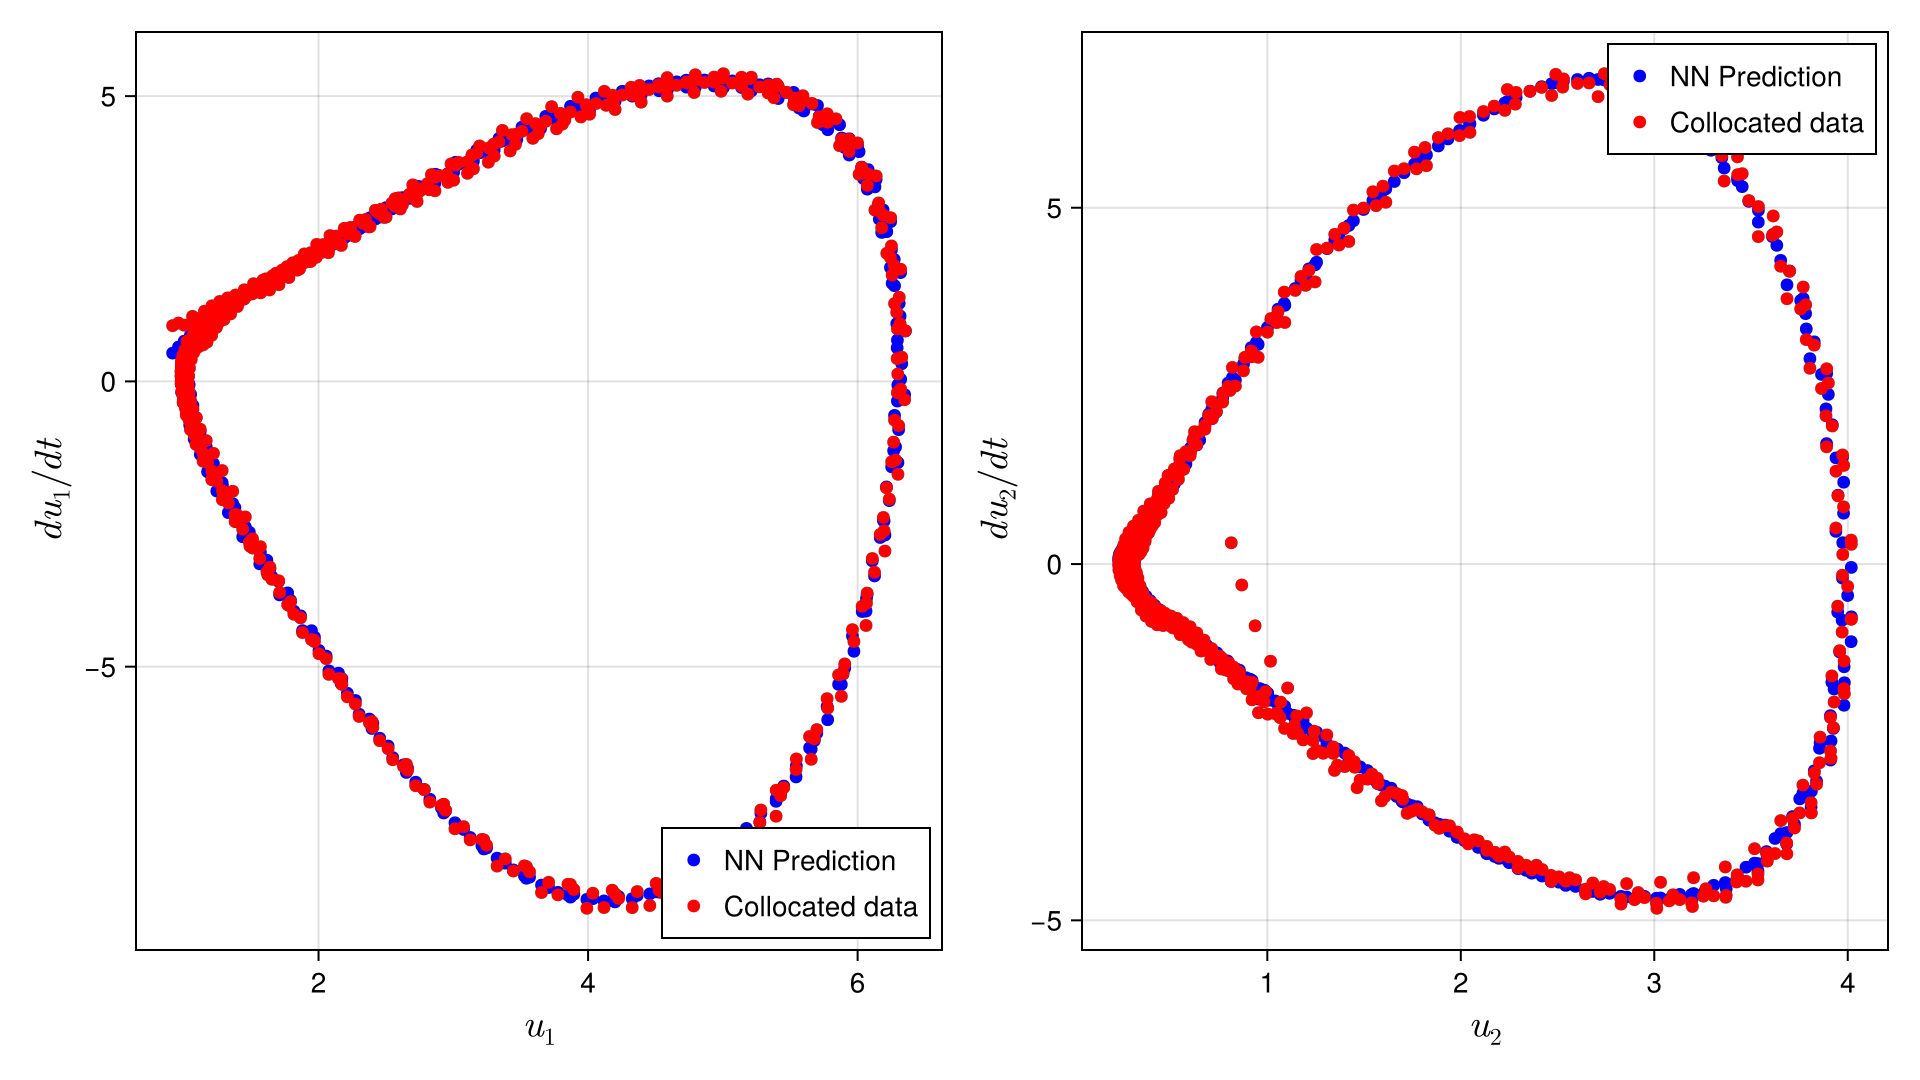

In [16]:
du_pred,_=dudtNODEs(u, result_neuralode.u, st)
fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"u_1",
    ylabel=L"du_1/dt")
CairoMakie.scatter!(ax1,u[1,:],du_pred[1,:],marker=:circle,color=:blue,label="NN Prediction")
CairoMakie.scatter!(ax1,u[1,:],du[1,:],marker=:circle,color=:red, label="Collocated data")
axislegend(ax1;position=:rb)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"u_2",
    ylabel=L"du_2/dt")
CairoMakie.scatter!(ax2,u[2,:],du_pred[2,:],marker=:circle,color=:blue,label="NN Prediction")
CairoMakie.scatter!(ax2,u[2,:],du[2,:],marker=:circle,color=:red, label="Collocated data")
axislegend(ax2;position=:rt)

#save("result_collocation_training.png", fig)
fig


Predict using model for collocation training and compare with validation data

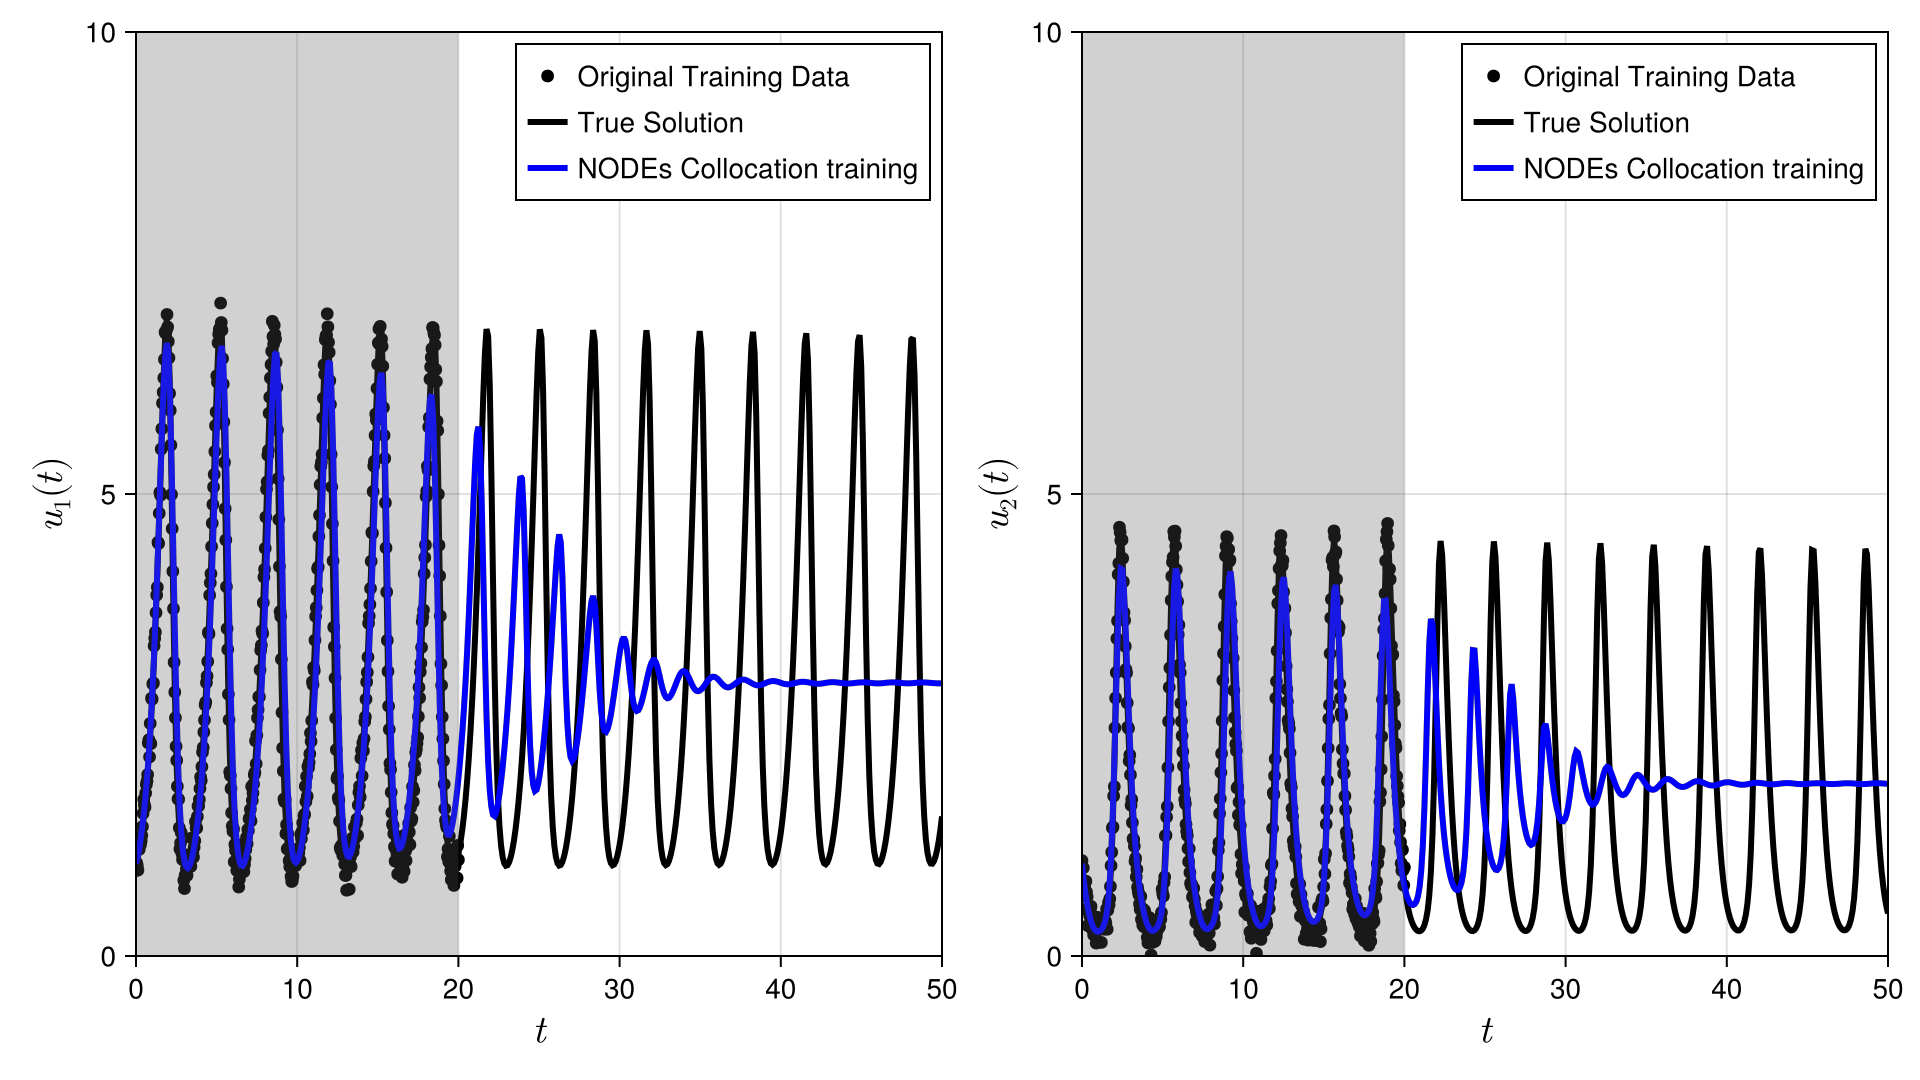

In [17]:
smodel_colloc = StatefulLuxLayer(dudtNODEs, result_neuralode, st)
dudt_colloc(u, p, t) = smodel_colloc(u, p)
prob_colloc = ODEProblem(dudt_colloc, u0, (tspan2[1], tspan2[2]),result_neuralode.u)
nn_sol_colloc = solve(prob_colloc, Tsit5(); saveat=tsteps2)
ComputedSolutionColloc=convert(AbstractArray,nn_sol_colloc)

fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")

CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax1,nn_sol_colloc.t,ComputedSolutionColloc[1,:]; linewidth = 3,color=:blue,label="NODEs Collocation training")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,0,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax2,nn_sol_colloc.t,ComputedSolutionColloc[2,:]; linewidth = 3,color=:blue,label="NODEs Collocation training")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,0,10)
#save("figures/07LotkaVolterraCollocationResults.png", fig)
fig

Now do NODEs training using the adjoint method

In [18]:
smodel = StatefulLuxLayer(dudtNODEs, result_neuralode, st)

function loss_adjoint(θ, (u, t))
    u0 = u[:, 1]
    dudt(u, p, t) = smodel(u, p)
    prob = ODEProblem(dudt, u0, (t[1], t[end]), θ)
    sol = solve(prob, Tsit5();  saveat=t)
    pred = stack(sol.u)

    return MSELoss()(pred, u)
end

loss_history = Float64[]
opt_func = OptimizationFunction(loss_adjoint, Optimization.AutoZygote())
opt_prob = OptimizationProblem(opt_func, result_neuralode.u, (data,tsteps))
numerical_neuralode = Optimization.solve(opt_prob, Optimisers.Adam(learning_rate); callback, epochs = max_iter_NODEs)
loss_history_NODEs=copy(loss_history)


Iteration: 100, Loss: 2.847590892490758
Iteration: 200, Loss: 2.808634553905581
Iteration: 300, Loss: 2.7966560843032293
Iteration: 400, Loss: 2.787302893338053
Iteration: 500, Loss: 2.773392588144743
Iteration: 600, Loss: 2.7485237513014273
Iteration: 700, Loss: 2.6953660239810384
Iteration: 800, Loss: 2.606802087642056
Iteration: 900, Loss: 2.559797404602675
Iteration: 1000, Loss: 2.702077187742233
Iteration: 1100, Loss: 1.5352960441823844
Iteration: 1200, Loss: 0.1296543693001375
Iteration: 1300, Loss: 0.11488691740698366
Iteration: 1400, Loss: 0.06354097346663415
Iteration: 1500, Loss: 0.07748116796193487
Iteration: 1600, Loss: 0.06700192491880816
Iteration: 1700, Loss: 0.08222651956055556
Iteration: 1800, Loss: 0.033544770306409594
Iteration: 1900, Loss: 0.19615437454583884
Iteration: 2000, Loss: 0.05447451967582194
Iteration: 2000, Loss: 0.030413476409523466


2001-element Vector{Float64}:
 5.327682088911264
 2.662362052207052
 2.7187596887036265
 2.7705511482156653
 2.815317433851543
 2.853812950889268
 2.886035902117553
 2.9125020753196305
 2.9332022658110684
 2.949646189572269
 ⋮
 0.033010489596919795
 0.030413476409523466
 0.03496270523460293
 0.04226011337959806
 0.053322368834530634
 0.05556518944045784
 0.05949454625629353
 0.05447451967582194
 0.030413476409523466

Predict using NODEs solution and plot

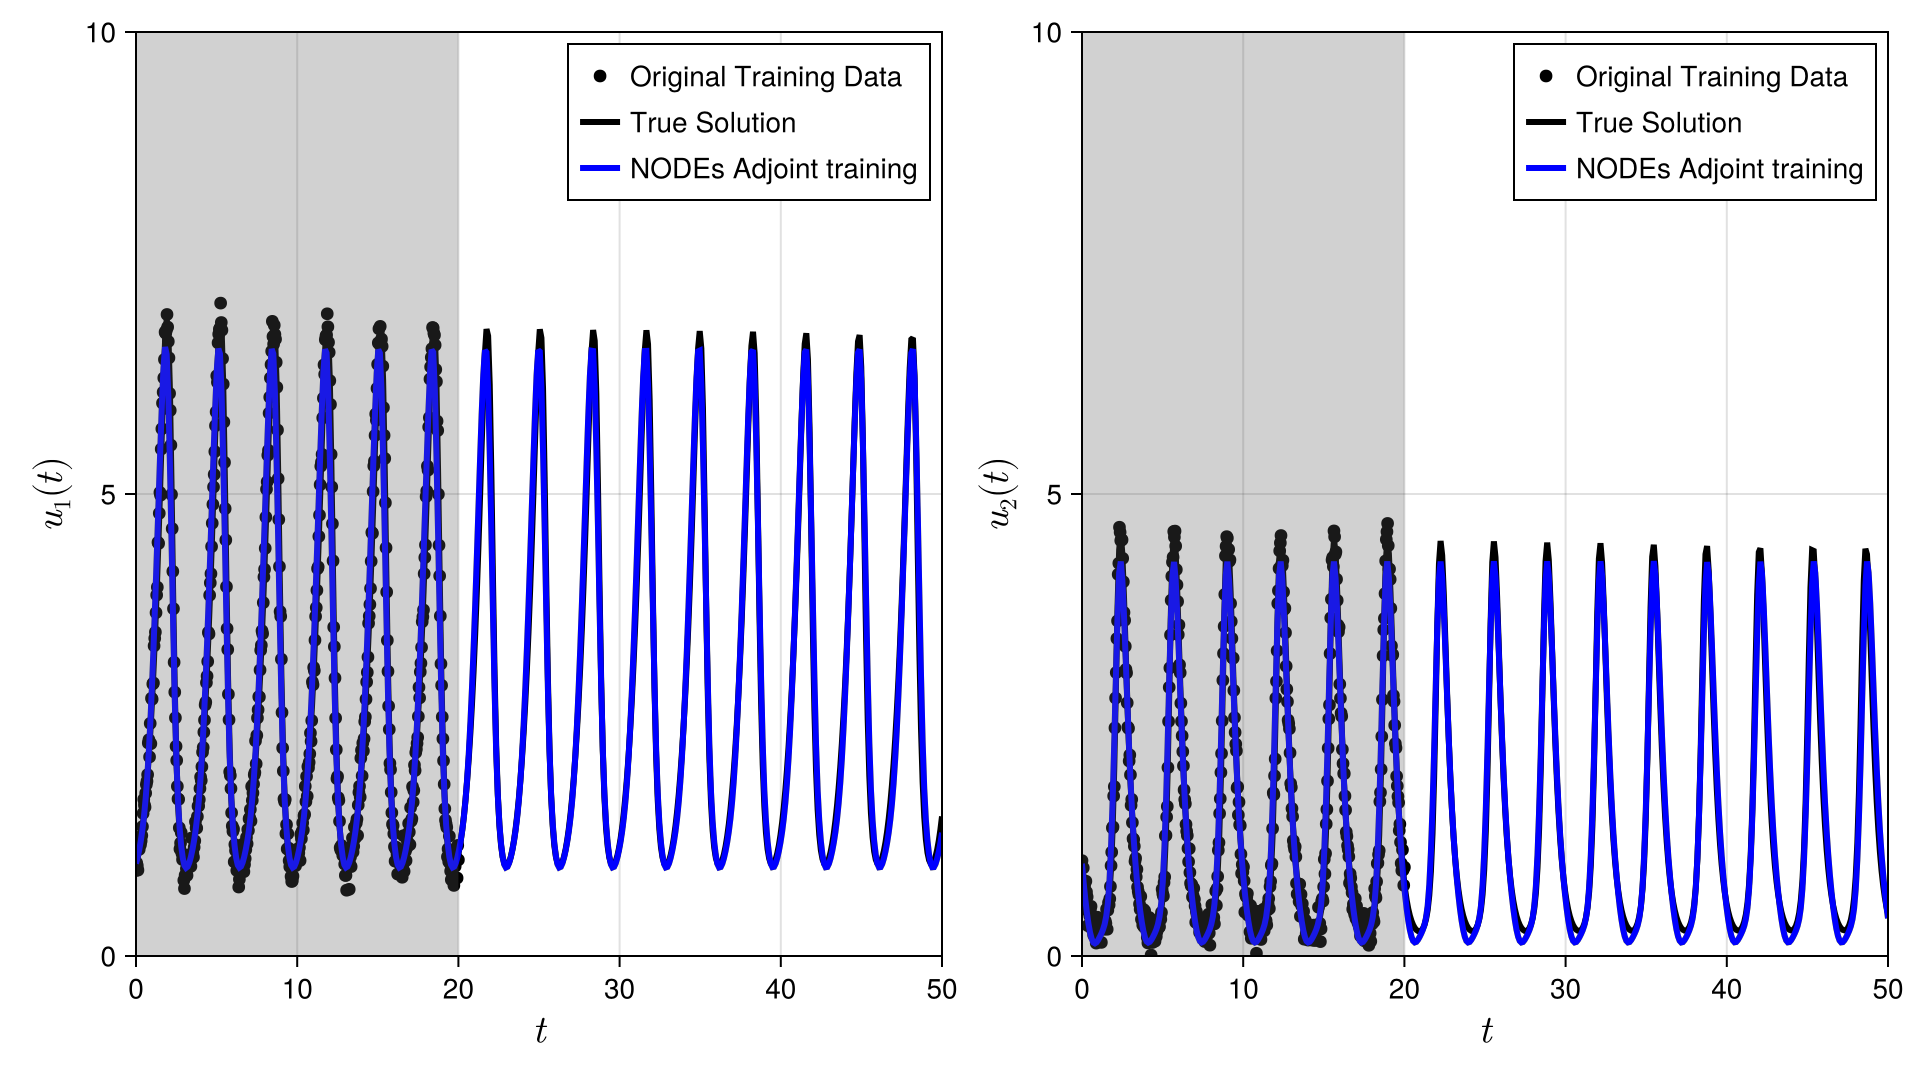

In [19]:
trained_model=StatefulLuxLayer(dudtNODEs, numerical_neuralode.u, smodel.st)
Finaldudt(u, p, tplot) = trained_model(u, p)
prob = ODEProblem(Finaldudt, u0, (tspan2[1],tspan2[2]), numerical_neuralode.u) 
nn_sol = solve(prob, Tsit5(); saveat=tsteps2)


ComputedSolution_nodes=convert(AbstractArray,nn_sol)


fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")

CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax1,nn_sol_colloc.t,ComputedSolution_nodes[1,:]; linewidth = 3,color=:blue,label="NODEs Adjoint training")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,0,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax2,nn_sol_colloc.t,ComputedSolution_nodes[2,:]; linewidth = 3,color=:blue,label="NODEs Adjoint training")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,0,10)
#save("figures/07LotkaVolterraNODEsResults.png", fig)
fig

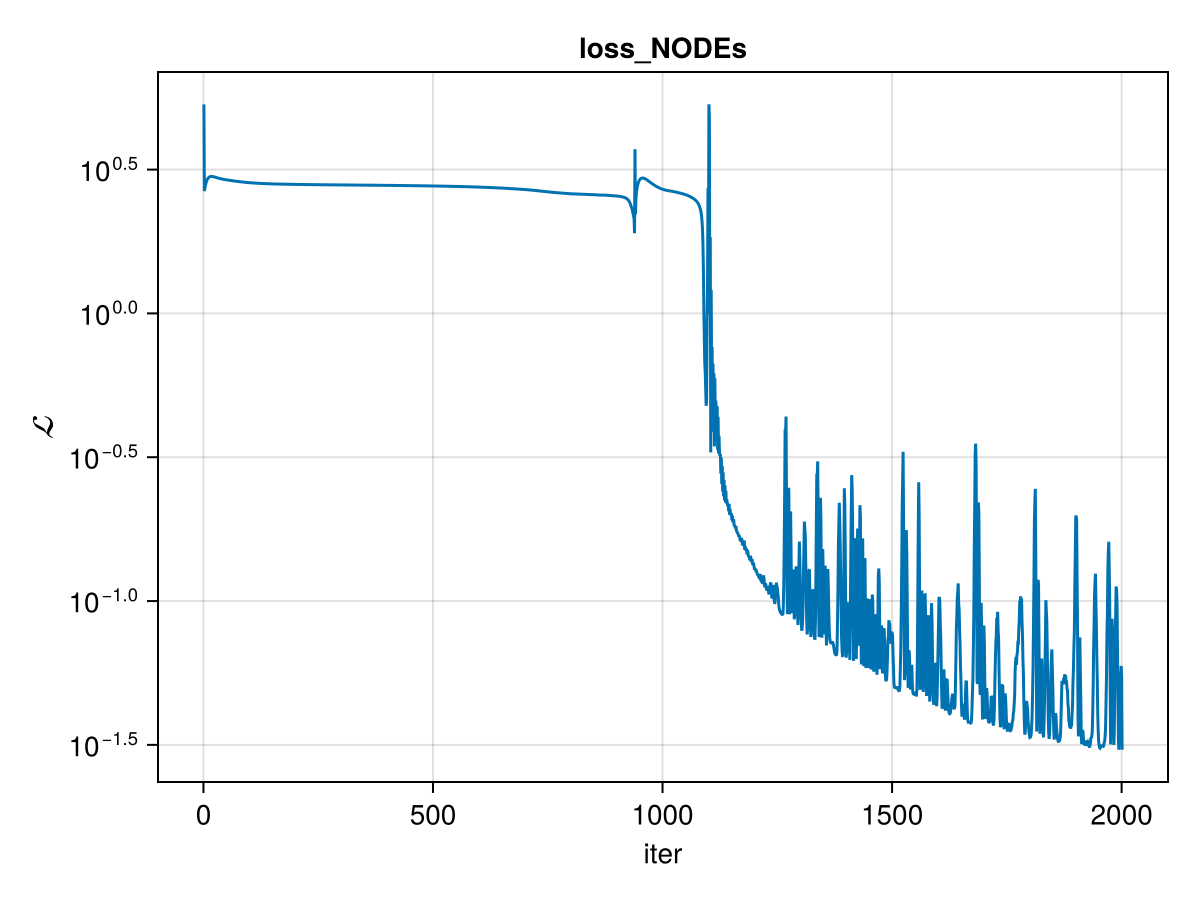

In [20]:
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel=L"\mathcal{L}",title="loss_NODEs")
CairoMakie.lines!(ax,loss_history_NODEs)
fig